# PLS (Partial Least Squares) Regression - CUCOMOF Dataset
Dự đoán nồng độ glucose (mM) từ cường độ dòng điện (µA) tại các mốc điện thế.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [2]:
df = pd.read_csv('CUCOMOF_processed.csv')
print(f'Shape: {df.shape}')
print(f'Số mẫu: {len(df)}')
print(f'Số features: {len(df.columns) - 1}')
df

Shape: (10, 12)
Số mẫu: 10
Số features: 11


,glucose_mM,V_-0.2,V_-0.1,V_-0.0,V_0.1,V_0.2,V_0.3,V_0.4,V_0.5,V_0.6,V_0.7,V_0.8
0,0.5,-22.86434,-2.64645,0.21458,3.07560,17.61913,93.24599,349.97607,694.68311,887.51648,1275.90186,2441.91650
1,1.0,-8.13007,-0.16689,1.21593,3.07560,15.95020,95.29639,386.35873,904.25348,1277.09387,1486.47400,2391.18091
2,1.5,-8.13007,-0.16689,1.21593,3.07560,15.95020,95.29639,386.35873,904.25348,1277.09387,1486.47400,2391.18091
3,2.0,-5.79357,0.16689,1.12057,2.93255,15.33031,88.81140,372.29205,954.51257,1512.22327,1826.60291,2233.91919
4,2.5,-10.89573,-0.59605,1.16825,3.40939,20.24174,116.94479,447.68048,1047.59119,1556.09229,1789.31421,2181.13330
5,3.0,-6.93798,-0.02384,1.21593,3.26633,18.33439,103.83177,406.76736,1003.29303,1598.91272,1966.74634,2207.35938
6,3.5,-6.89030,0.02384,1.21593,3.17097,18.38207,106.12059,424.60107,1061.99170,1685.07715,2049.85913,2275.83301
7,4.0,-6.46114,0.07153,1.16825,3.17097,18.28671,104.45166,417.44852,1060.56116,1755.41113,2239.45044,2446.54175
8,4.5,-6.98566,-0.02384,1.16825,3.36170,19.43111,106.74048,404.33551,996.37891,1660.61548,2165.39771,2425.70410
9,5.0,-6.65188,0.02384,1.16825,3.31402,19.04964,104.59471,397.99356,999.00153,1694.61438,2238.49683,2541.95679


In [3]:
# Tách X và y
X = df.drop(columns=['glucose_mM']).values
y = df['glucose_mM'].values
feature_names = df.drop(columns=['glucose_mM']).columns.tolist()

print(f'X shape: {X.shape}')
print(f'y: {y}')

X shape: (10, 11)
y: [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


## 2. Chọn số Components tối ưu

In [4]:
# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dùng Leave-One-Out CV để chọn số components tối ưu
loo = LeaveOneOut()
max_components = min(len(df) - 1, X.shape[1])  # tối đa n-1 hoặc số features

rmse_cv = []
r2_cv = []

for n_comp in range(1, max_components + 1):
    pls = PLSRegression(n_components=n_comp)
    y_pred_cv = cross_val_predict(pls, X_scaled, y, cv=loo)
    rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
    r2 = r2_score(y, y_pred_cv)
    rmse_cv.append(rmse)
    r2_cv.append(r2)
    print(f'n_components={n_comp}: RMSE={rmse:.4f}, R²={r2:.4f}')

best_n = np.argmin(rmse_cv) + 1
print(f'\n✅ Số components tối ưu: {best_n} (RMSE={rmse_cv[best_n-1]:.4f})')

n_components=1: RMSE=0.9527, R²=0.5600
n_components=2: RMSE=0.9664, R²=0.5472
n_components=3: RMSE=0.8313, R²=0.6650
n_components=4: RMSE=0.4632, R²=0.8960
n_components=5: RMSE=0.7848, R²=0.7014
n_components=6: RMSE=1.0598, R²=0.4554
n_components=7: RMSE=0.9854, R²=0.5292
n_components=8: RMSE=4.6271, R²=-9.3806
n_components=9: RMSE=5.0251, R²=-11.2434

✅ Số components tối ưu: 4 (RMSE=0.4632)


d:\Github\Machine-Learning-Studies\tf-env\lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 8
  warnings.warn(f"y residual is constant at iteration {k}")
d:\Github\Machine-Learning-Studies\tf-env\lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 8
  warnings.warn(f"y residual is constant at iteration {k}")


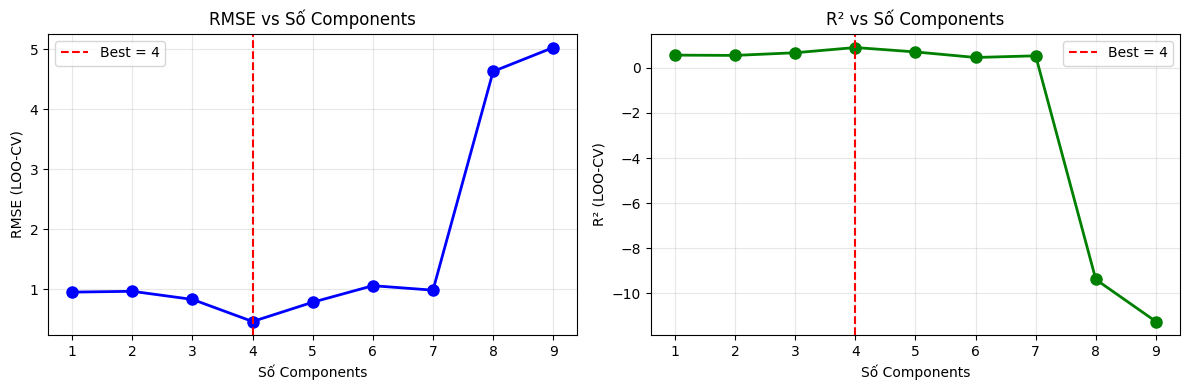

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

components = range(1, max_components + 1)

ax1.plot(components, rmse_cv, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=best_n, color='red', linestyle='--', label=f'Best = {best_n}')
ax1.set_xlabel('Số Components')
ax1.set_ylabel('RMSE (LOO-CV)')
ax1.set_title('RMSE vs Số Components')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(components, r2_cv, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_n, color='red', linestyle='--', label=f'Best = {best_n}')
ax2.set_xlabel('Số Components')
ax2.set_ylabel('R² (LOO-CV)')
ax2.set_title('R² vs Số Components')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pls_components_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Huấn luyện mô hình PLS tối ưu

In [6]:
# Train model với số components tối ưu
pls_best = PLSRegression(n_components=best_n)
pls_best.fit(X_scaled, y)

# Dự đoán train set
y_pred_train = pls_best.predict(X_scaled).ravel()

# Dự đoán LOO-CV
y_pred_cv = cross_val_predict(pls_best, X_scaled, y, cv=LeaveOneOut()).ravel()

# Metrics
r2_train = r2_score(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
r2_loo = r2_score(y, y_pred_cv)
rmse_loo = np.sqrt(mean_squared_error(y, y_pred_cv))

print('=== Kết quả mô hình PLS ===')
print(f'Số components: {best_n}')
print(f'\nTrain Set:')
print(f'  R²     = {r2_train:.4f}')
print(f'  RMSE   = {rmse_train:.4f} mM')
print(f'\nLOO Cross-Validation:')
print(f'  R²     = {r2_loo:.4f}')
print(f'  RMSE   = {rmse_loo:.4f} mM')

=== Kết quả mô hình PLS ===
Số components: 4

Train Set:
  R²     = 0.9853
  RMSE   = 0.1742 mM

LOO Cross-Validation:
  R²     = 0.8960
  RMSE   = 0.4632 mM


## 4. Predicted vs Actual

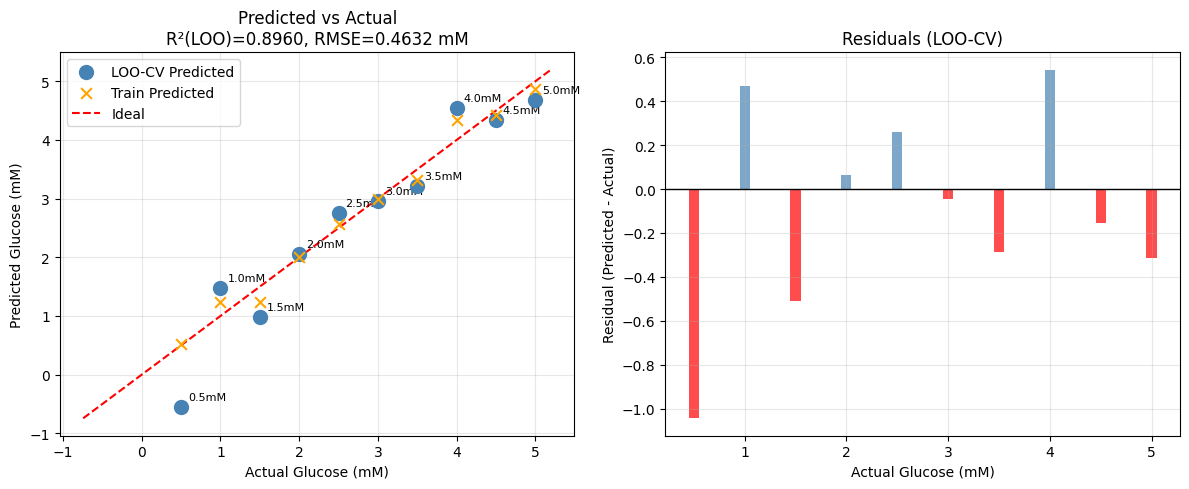

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Predicted vs Actual ---
ax = axes[0]
ax.scatter(y, y_pred_cv, color='steelblue', s=100, zorder=5, label='LOO-CV Predicted')
ax.scatter(y, y_pred_train, color='orange', s=60, marker='x', zorder=6, label='Train Predicted')

# Đường lý tưởng y=x
lim = [min(y.min(), y_pred_cv.min()) - 0.2, max(y.max(), y_pred_cv.max()) + 0.2]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Ideal')

for i, (actual, pred) in enumerate(zip(y, y_pred_cv)):
    ax.annotate(f'{actual}mM', (actual, pred), textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Actual Glucose (mM)')
ax.set_ylabel('Predicted Glucose (mM)')
ax.set_title(f'Predicted vs Actual\nR²(LOO)={r2_loo:.4f}, RMSE={rmse_loo:.4f} mM')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Residuals ---
ax2 = axes[1]
residuals = y_pred_cv - y
ax2.bar(y, residuals, width=0.1, color=['red' if r < 0 else 'steelblue' for r in residuals], alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_xlabel('Actual Glucose (mM)')
ax2.set_ylabel('Residual (Predicted - Actual)')
ax2.set_title('Residuals (LOO-CV)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pls_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. VIP Scores (Variable Importance in Projection)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19944\1120289508.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * (s.T @ weight) / total_s)


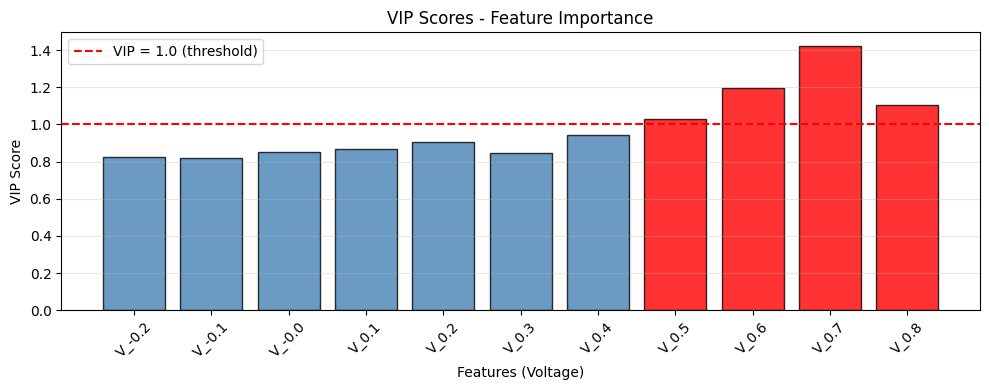


VIP Scores:
     V_-0.2: 0.8237
     V_-0.1: 0.8175
     V_-0.0: 0.8522
     V_0.1: 0.8694
     V_0.2: 0.9068
     V_0.3: 0.8473
     V_0.4: 0.9439
  ⭐ V_0.5: 1.0288
  ⭐ V_0.6: 1.1971
  ⭐ V_0.7: 1.4247
  ⭐ V_0.8: 1.1038


In [8]:
def vip_scores(pls_model):
    """Tính VIP scores cho PLS model"""
    t = pls_model.x_scores_
    w = pls_model.x_weights_
    q = pls_model.y_loadings_
    p, h = w.shape
    vips = np.zeros((p,))
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 for j in range(h)])
        vips[i] = np.sqrt(p * (s.T @ weight) / total_s)
    return vips

vip = vip_scores(pls_best)

plt.figure(figsize=(10, 4))
colors = ['red' if v >= 1.0 else 'steelblue' for v in vip]
bars = plt.bar(feature_names, vip, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='VIP = 1.0 (threshold)')
plt.xlabel('Features (Voltage)')
plt.ylabel('VIP Score')
plt.title('VIP Scores - Feature Importance')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('pls_vip_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVIP Scores:')
for name, score in zip(feature_names, vip):
    marker = '⭐' if score >= 1.0 else '  '
    print(f'  {marker} {name}: {score:.4f}')

## 6. PLS Components Scores Plot

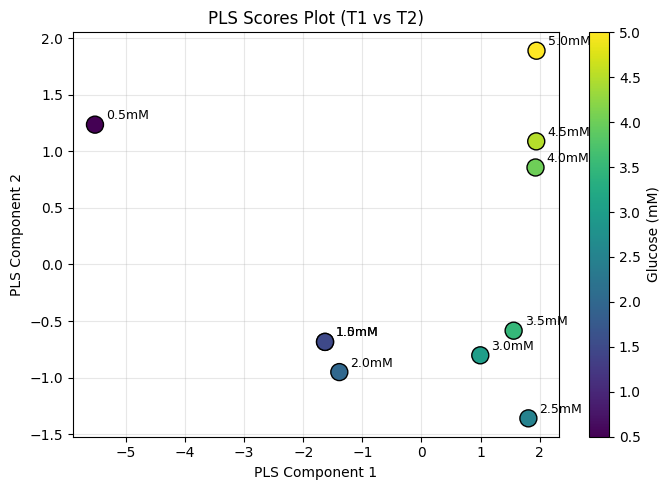

In [9]:
if best_n >= 2:
    T = pls_best.x_scores_
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(T[:, 0], T[:, 1], c=y, cmap='viridis', s=150, edgecolor='black', zorder=5)
    for i, conc in enumerate(y):
        plt.annotate(f'{conc}mM', (T[i, 0], T[i, 1]), textcoords='offset points', xytext=(8, 4), fontsize=9)
    plt.colorbar(scatter, label='Glucose (mM)')
    plt.xlabel('PLS Component 1')
    plt.ylabel('PLS Component 2')
    plt.title('PLS Scores Plot (T1 vs T2)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pls_scores_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Chỉ có 1 component, không vẽ được scores plot 2D.')

## 7. Tổng kết kết quả

In [10]:
results = pd.DataFrame({
    'Actual (mM)': y,
    'Predicted LOO-CV (mM)': y_pred_cv.round(4),
    'Residual': (y_pred_cv - y).round(4),
    'Abs Error': np.abs(y_pred_cv - y).round(4)
})

print('=== Bảng kết quả dự đoán ===')
print(results.to_string(index=False))
print(f'\nMean Abs Error: {results["Abs Error"].mean():.4f} mM')
print(f'R² (LOO-CV):   {r2_loo:.4f}')
print(f'RMSE (LOO-CV): {rmse_loo:.4f} mM')

=== Bảng kết quả dự đoán ===
 Actual (mM)  Predicted LOO-CV (mM)  Residual  Abs Error
         0.5                -0.5444   -1.0444     1.0444
         1.0                 1.4693    0.4693     0.4693
         1.5                 0.9903   -0.5097     0.5097
         2.0                 2.0636    0.0636     0.0636
         2.5                 2.7617    0.2617     0.2617
         3.0                 2.9538   -0.0462     0.0462
         3.5                 3.2155   -0.2845     0.2845
         4.0                 4.5444    0.5444     0.5444
         4.5                 4.3444   -0.1556     0.1556
         5.0                 4.6853   -0.3147     0.3147

Mean Abs Error: 0.3694 mM
R² (LOO-CV):   0.8960
RMSE (LOO-CV): 0.4632 mM
